In [9]:
# ================================================
# QA Architect - Modelo de Predicción de Defectos
# Unidad 1 - Machine Learning y Deep Learning
# ================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import warnings

In [ ]:
# 1. Cargar datos
# =====================

# Descarga el dataset de Kaggle

# Descargar el Dataset desde aqui: https://www.kaggle.com/code/rajneesh231/software-defect-prediction
from IPython.core import payload
df = pd.read_csv('../data/SoftwareDefectDataset.csv') 

# Visualiza las primeras clases
print("Shape del dataset:", df.shape)
print("\nPrimeras filas:")
print(df.head())

# Count de la cantidad de Defect labels
print("\nDistribución de la clase objetivo:")
print(df['DEFECT_LABEL'].value_counts(normalize=True)) 

Shape del dataset: (1000, 11)

Primeras filas:
        LOC     CYCLO    LENGTH    VOLUME  DIFFICULTY  INT_FAN_IN  \
0  0.779239  0.478261  0.274048  0.544918    0.564121    0.222222   
1  0.595156  0.608696  0.742561  0.758597    0.450649    0.222222   
2  0.895502  0.000000  0.968166  0.754277    0.672996    1.000000   
3  0.782007  0.565217  0.164706  0.017766    0.584106    0.000000   
4  0.757785  0.217391  0.560900  0.126125    0.526050    0.555556   

   INT_FAN_OUT  NUM_OPERATORS  NUM_OPERANDS  BRANCH_COUNT  DEFECT_LABEL  
0     0.444444       0.736196      0.807377      0.642857             0  
1     0.000000       0.576687      0.200820      0.142857             0  
2     0.000000       0.116564      0.020492      0.000000             1  
3     1.000000       0.615542      0.481557      0.500000             0  
4     0.222222       0.656442      0.655738      0.857143             1  

Distribución de la clase objetivo:
DEFECT_LABEL
0    0.674
1    0.326
Name: proportion, dtype

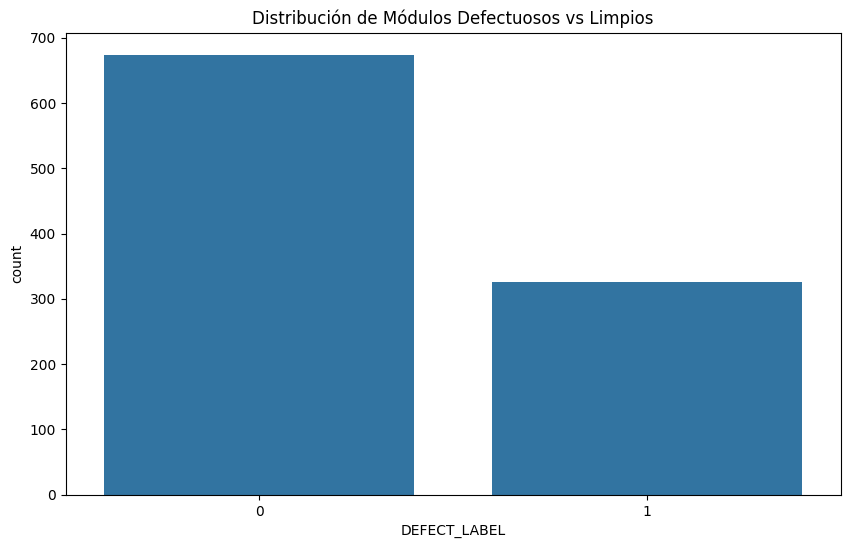

In [11]:
# 2. Exploración rápida
# =====================
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='DEFECT_LABEL')
plt.title('Distribución de Módulos Defectuosos vs Limpios')
plt.show()

In [12]:
# 3. Preparación de datos
# =====================

# Separar features y target
X = df.drop(['DEFECT_LABEL'], axis=1)
y = df['DEFECT_LABEL']

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Datos preparados. Train:", X_train.shape, "Test:", X_test.shape)

Datos preparados. Train: (800, 10) Test: (200, 10)


In [13]:
# 4. Entrenamiento del modelo
# =====================

# Opción 1: Logistic Regression. Importante para clasificacion binaria
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Opción 2: RandomForest
# model = RandomForestClassifier(n_estimators=200, random_state=42)
# model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

=== Resultados del Modelo ===
Accuracy: 0.67
ROC AUC: 0.4788603988603989

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.99      0.80       135
           1       0.00      0.00      0.00        65

    accuracy                           0.67       200
   macro avg       0.34      0.50      0.40       200
weighted avg       0.45      0.67      0.54       200



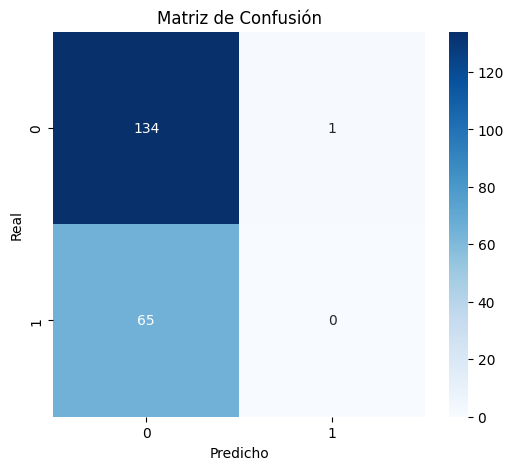

In [14]:
# 5. Evaluación
# =====================

y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("=== Resultados del Modelo ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Matriz de confusión
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

In [15]:
# 6. Feature Importance
# =====================
if hasattr(model, 'coef_'):  # Logistic
    importance = pd.DataFrame({
        'feature': X.columns,
        'importance': abs(model.coef_[0])
    }).sort_values('importance', ascending=False)
else:  # RandomForest
    importance = pd.DataFrame({
        'feature': X.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)

print("\nTop 10 métricas más importantes para predecir defectos:")
print(importance.head(10))


Top 10 métricas más importantes para predecir defectos:
         feature  importance
8   NUM_OPERANDS    0.130919
2         LENGTH    0.122958
9   BRANCH_COUNT    0.110451
7  NUM_OPERATORS    0.091067
0            LOC    0.089730
3         VOLUME    0.047768
4     DIFFICULTY    0.038125
5     INT_FAN_IN    0.021839
6    INT_FAN_OUT    0.021748
1          CYCLO    0.012024


In [17]:
# Guardar modelo
import joblib
joblib.dump(model, '../model/defect_prediction_model.pkl')
joblib.dump(scaler, '../model/scaler.pkl')

['../model/scaler.pkl']